In [1]:
import pandas as pd 
import numpy as mp
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df=pd.read_excel('online_retail_II.xlsx')

In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 38.8+ MB


In [5]:
df.shape

(525461, 8)

In [6]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845018,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [7]:
df.describe(include='all')

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,525461.0,525461,522533,525461.000000,525461,525461.000000,417534.000000,525461
unique,28816.0,4632,4681,NaN,NaN,NaN,NaN,40
top,537434.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,675.0,3516,3549,NaN,NaN,NaN,NaN,485852
mean,NaN,NaN,NaN,10.337667,2010-06-28 11:37:36.845018,4.688834,15360.645478,NaN
min,NaN,NaN,NaN,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2010-03-21 12:20:00,1.250000,13983.000000,NaN
50%,NaN,NaN,NaN,3.000000,2010-07-06 09:51:00,2.100000,15311.000000,NaN
75%,NaN,NaN,NaN,10.000000,2010-10-15 12:45:00,4.210000,16799.000000,NaN
max,NaN,NaN,NaN,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000,NaN


In [8]:
# null values 
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [9]:
df['Description'].nunique()

4681

In [10]:
# investigating null values in customer column
missing_customer=df[df["Customer ID"].isna()]
missing_customer

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
525231,538159,21324,NaN,-18,2010-12-09 17:17:00,0.00,NaN,United Kingdom
525232,538158,20892,NaN,-32,2010-12-09 17:17:00,0.00,NaN,United Kingdom
525233,538160,20956,NaN,288,2010-12-09 17:18:00,0.00,NaN,United Kingdom
525234,538161,46000S,Dotcom sales,-100,2010-12-09 17:25:00,0.00,NaN,United Kingdom


In [11]:
missing_customer.shape[0]

107927

In [12]:
missing_customer.shape[0]/df.shape[0]*100

20.53948818275762

In [13]:
df['Description'].isnull().sum()/df.shape[0]*100

np.float64(0.5572249891048051)

In [14]:
(missing_customer['Quantity']<0).value_counts()

Quantity
False    105440
True       2487
Name: count, dtype: int64

In [15]:
(missing_customer['Price']==0).sum()

np.int64(3656)

In [16]:
negative_pct = (missing_customer["Quantity"] < 0).mean() * 100
negative_pct

np.float64(2.304335337774607)

In [17]:
zero_price_pct = (missing_customer["Price"] == 0).mean() * 100
zero_price_pct

np.float64(3.3874748672713966)

In [18]:
negative_qty = df[df["Quantity"] < 0]
negative_qty

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
525231,538159,21324,NaN,-18,2010-12-09 17:17:00,0.00,NaN,United Kingdom
525232,538158,20892,NaN,-32,2010-12-09 17:17:00,0.00,NaN,United Kingdom
525234,538161,46000S,Dotcom sales,-100,2010-12-09 17:25:00,0.00,NaN,United Kingdom
525235,538162,46000M,Dotcom sales,-100,2010-12-09 17:25:00,0.00,NaN,United Kingdom


In [19]:
negative_qty["Invoice"].astype(str).str.startswith("C").value_counts()

Invoice
True     10205
False     2121
Name: count, dtype: int64

In [20]:
negative_non_c = df[(df["Quantity"] < 0) & (~df["Invoice"].astype(str).str.startswith("C"))]
negative_non_c

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
524458,538092,37467,NaN,-177,2010-12-09 14:49:00,0.0,NaN,United Kingdom
525231,538159,21324,NaN,-18,2010-12-09 17:17:00,0.0,NaN,United Kingdom
525232,538158,20892,NaN,-32,2010-12-09 17:17:00,0.0,NaN,United Kingdom
525234,538161,46000S,Dotcom sales,-100,2010-12-09 17:25:00,0.0,NaN,United Kingdom


In [21]:
negative_non_c["Price"].describe()

count    2121.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: Price, dtype: float64

In [22]:
(negative_non_c["Quantity"]<0).sum()

np.int64(2121)

In [23]:
negative_non_c["Description"].value_counts().head(20)

Description
?                         42
damages                   39
damaged                   36
missing                   24
dotcom                     6
given away                 6
smashed                    5
checked                    5
MIA                        4
Damages                    4
ebay sales                 4
crushed                    4
No Stock                   3
Damaged                    3
counted                    3
check                      3
discoloured                2
damages?                   2
Dotcom                     2
damages, lost bits etc     2
Name: count, dtype: int64

In [24]:
negative_non_c['StockCode'].value_counts().head(20)

StockCode
22423     9
46000M    5
84016     5
20852     5
71477     4
21768     4
21493     3
21489     3
21490     3
79030A    3
10138     3
72739B    3
37503     3
72739C    3
17129D    3
84997D    3
35918B    3
84845C    3
21760     3
84653     3
Name: count, dtype: int64

In [25]:
cancelled = df[df["Invoice"].astype(str).str.startswith("C")]
cancelled.shape

(10206, 8)

In [26]:
cancelled["Quantity"].describe()

count    10206.000000
mean       -20.911033
std        208.261710
min      -9360.000000
25%         -6.000000
50%         -2.000000
75%         -1.000000
max          1.000000
Name: Quantity, dtype: float64

In [27]:
cancelled[cancelled["Quantity"]>0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
76799,C496350,M,Manual,1,2010-02-01 08:24:00,373.57,NaN,United Kingdom


In [28]:
df[df["Price"] <= 0].shape

(3690, 8)

In [29]:
df[df["Price"] <= 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
525231,538159,21324,NaN,-18,2010-12-09 17:17:00,0.0,NaN,United Kingdom
525232,538158,20892,NaN,-32,2010-12-09 17:17:00,0.0,NaN,United Kingdom
525233,538160,20956,NaN,288,2010-12-09 17:18:00,0.0,NaN,United Kingdom
525234,538161,46000S,Dotcom sales,-100,2010-12-09 17:25:00,0.0,NaN,United Kingdom


In [30]:
df[df["Price"] <= 0]["Description"].value_counts().head(30)

Description
?                                      45
damages                                39
damaged                                38
missing                                24
OWL DOORSTOP                            8
checked                                 8
POLYESTER FILLER PAD 45x45cm            7
PICNIC BASKET WICKER LARGE              7
FLAG OF ST GEORGE CAR FLAG              6
dotcom                                  6
HEART OF WICKER SMALL                   6
AIRLINE BAG VINTAGE WORLD CHAMPION      6
given away                              6
smashed                                 5
POLYESTER FILLER PAD 40x40cm            5
SMALL POPCORN HOLDER                    5
WATERING CAN BLUE ELEPHANT              5
ENAMEL FIRE BUCKET CREAM                5
ENAMEL WASH BOWL CREAM                  5
PICNIC BASKET WICKER SMALL              5
IVORY KITCHEN SCALES                    5
MIA                                     4
Damages                                 4
ebay sales            

In [31]:
df[df["Price"] < 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


# Data Quality & Initial Investigation — Findings

The dataset contains **525,461 transaction records across 8 variables**, covering retail transactions from **December 2009 to December 2010**.

## Key Data Quality Findings

### 1. Missing Customer IDs
- **107,927 records (~20.5%)** have missing `Customer ID`.

### 2. Missing Product Descriptions
- **2,928 records (~0.56%)** have missing `Description`.
- Since `StockCode` is available, these records do not necessarily represent invalid transactions.
- They will **not be removed solely because of a missing description**.

### 3. Negative Quantities
- **12,326 records** contain negative quantities.
- **10,205** negative-quantity records have invoice numbers beginning with `C`, indicating cancellation transactions.
- The remaining **2,121** records do not have the `C` prefix and have `Price = 0`.
- Their descriptions include terms such as `damaged`, `missing`, `smashed`, `given away`, and `MIA`, indicating operational adjustments, losses, or damaged-stock records rather than normal customer purchases.

### 4. Zero-Price Transactions
- **3,656 records** have `Price = 0`.
- These are predominantly associated with operational activities such as damages, missing stock, checks, giveaways, and other adjustments.
- Therefore, they should **not be interpreted as normal revenue-generating sales**.

### 5. Negative Prices
- Negative prices are associated with **accounting/bad-debt adjustments**, rather than product sales.
- These records have descriptions such as `Adjust bad debt`, extremely large negative values, and no associated `Customer ID`.
- They will therefore be **excluded from sales/revenue analysis**.

### 6. Manual Adjustment Anomaly
One `C`-prefixed record contains a positive quantity:

| Field | Value |
|---|---|
| `StockCode` | `M` |
| `Description` | `Manual` |
| `Quantity` | `1` |
| `Price` | `373.57` |
| `Customer ID` | Missing |


## Overall Conclusion

For customer-level sales analysis, we will focus on transactions with:

**`Customer ID` available + `Quantity > 0` + `Price > 0`**

The original dataset will be preserved, and a separate cleaned dataset will be created for further analysis.

In [32]:
# creating separate cleaned dataset
df1=df[(df['Customer ID'].notna()) & (df['Quantity']>0) & (df['Price']>0)]

In [33]:
df1

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [34]:
df1.shape

(407664, 8)

In [35]:
df1.info()

<class 'pandas.DataFrame'>
Index: 407664 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      407664 non-null  object        
 1   StockCode    407664 non-null  object        
 2   Description  407664 non-null  object        
 3   Quantity     407664 non-null  int64         
 4   InvoiceDate  407664 non-null  datetime64[us]
 5   Price        407664 non-null  float64       
 6   Customer ID  407664 non-null  float64       
 7   Country      407664 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.2+ MB


In [36]:
df1.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [37]:
# creating new column-revenue
df1['Revenue']=df1['Quantity']*df1['Price']
df1.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [38]:
df1.describe()

,Quantity,InvoiceDate,Price,Customer ID,Revenue
count,407664.000000,407664,407664.000000,407664.000000,407664.000000
mean,13.585585,2010-07-01 10:15:11.871688,3.294438,15368.592598,21.664909
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000,0.001000
25%,2.000000,2010-03-26 14:01:00,1.250000,13997.000000,4.950000
50%,5.000000,2010-07-09 15:47:00,1.950000,15321.000000,11.900000
75%,12.000000,2010-10-14 17:09:00,3.750000,16812.000000,19.500000
max,19152.000000,2010-12-09 20:01:00,10953.500000,18287.000000,15818.400000
std,96.840747,NaN,34.757965,1679.762138,77.150058


In [39]:
numeric_cols= df1.select_dtypes(include='number').columns

In [40]:
numeric_cols

Index(['Quantity', 'Price', 'Customer ID', 'Revenue'], dtype='str')

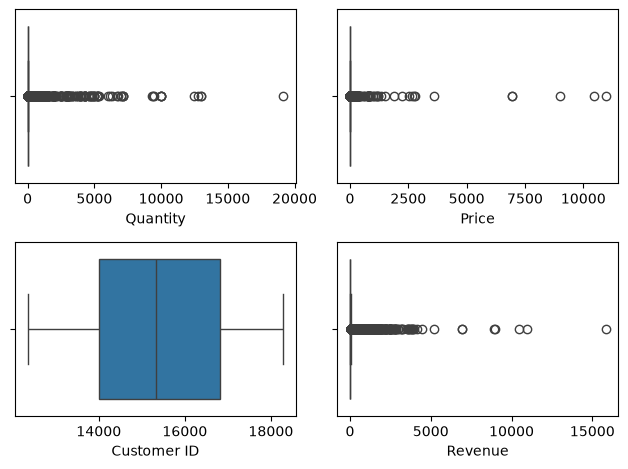

In [41]:
for i,col in enumerate(numeric_cols):
    plt.subplot(2,2,i+1)
    sns.boxplot(x=df1[col])
plt.tight_layout()
plt.show()

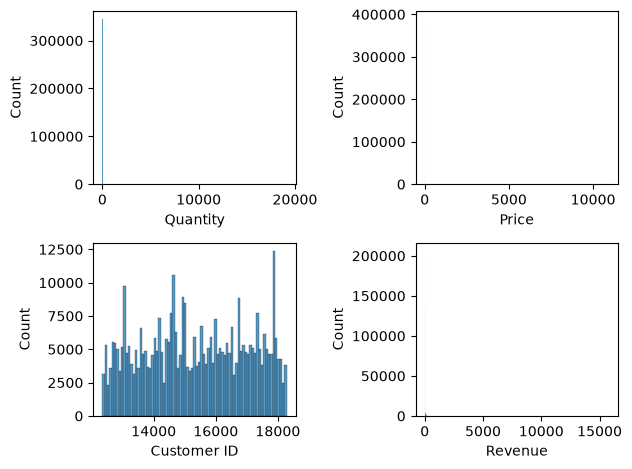

In [42]:
for i,col in enumerate(numeric_cols):
    plt.subplot(2,2,i+1)
    sns.histplot(df1[col])
plt.tight_layout()
plt.show()

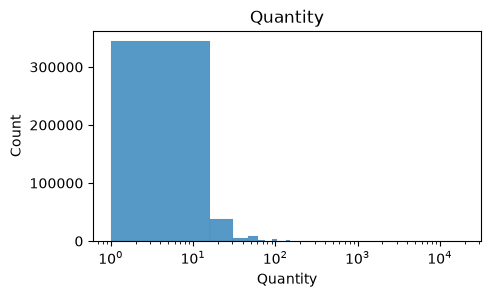

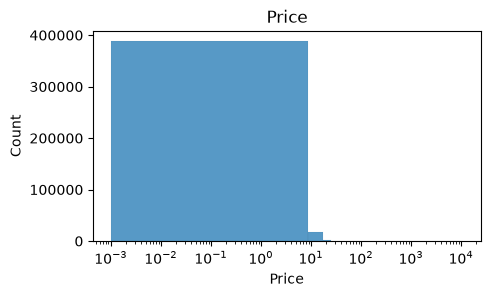

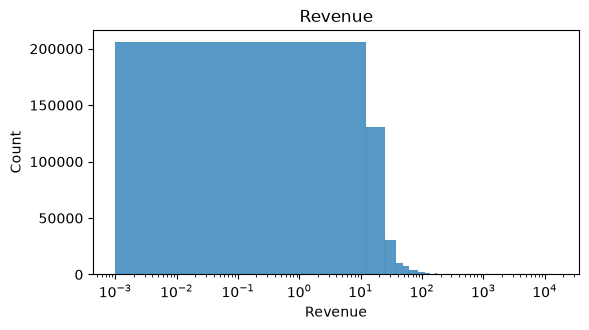

In [43]:
numeric_cols = ["Quantity", "Price", "Revenue"]

for i, col in enumerate(numeric_cols):
    plt.figure(figsize=(11,6))
    plt.subplot(2, 2, i+1)
    sns.histplot(df1[col])
    plt.title(col)
    plt.xscale('log')

plt.tight_layout()
plt.show()

In [44]:
for col in ["Quantity", "Price", "Revenue"]:
    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR
    
    outliers = (df1[col] > upper) | (df1[col] < lower)
    
    print(col)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print(f"Upper bound: {upper}, Lower bound: {lower}")
    print("Potential outliers:", outliers.sum())
    print("Outlier %:", round(outliers.mean() * 100, 2),'\n')

Quantity
Q1: 2.0
Q3: 12.0
Upper bound: 27.0, Lower bound: -13.0
Potential outliers: 26336
Outlier %: 6.46 

Price
Q1: 1.25
Q3: 3.75
Upper bound: 7.5, Lower bound: -2.5
Potential outliers: 32989
Outlier %: 8.09 

Revenue
Q1: 4.95
Q3: 19.5
Upper bound: 41.325, Lower bound: -16.875000000000004
Potential outliers: 33849
Outlier %: 8.3 



In [45]:
df1.nlargest(20, "Quantity")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
90857,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,2010-02-15 11:57:00,0.10,13902.0,Denmark,1915.20
127166,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,2010-03-17 13:09:00,0.10,13902.0,Denmark,1296.00
127168,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,2010-03-17 13:09:00,0.10,13902.0,Denmark,1296.00
127169,501534,21085,SET/6 WOODLAND PAPER CUPS,12744,2010-03-17 13:09:00,0.10,13902.0,Denmark,1274.40
127167,501534,21092,SET/6 STRAWBERRY PAPER PLATES,12480,2010-03-17 13:09:00,0.10,13902.0,Denmark,1248.00
135027,502269,21984,PACK OF 12 PINK PAISLEY TISSUES,10000,2010-03-23 15:36:00,0.25,17940.0,United Kingdom,2500.00
135028,502269,21982,PACK OF 12 SUKI TISSUES,10000,2010-03-23 15:36:00,0.25,17940.0,United Kingdom,2500.00
135029,502269,21980,PACK OF 12 RED SPOTTY TISSUES,10000,2010-03-23 15:36:00,0.25,17940.0,United Kingdom,2500.00
135030,502269,21981,PACK OF 12 WOODLAND TISSUES,10000,2010-03-23 15:36:00,0.25,17940.0,United Kingdom,2500.00
93677,498152,85220,SMALL FAIRY CAKE FRIDGE MAGNETS,9456,2010-02-17 10:51:00,0.30,13902.0,Denmark,2836.80


In [46]:
df1.nlargest(20, "Price")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
135013,502263,M,Manual,1,2010-03-23 15:22:00,10953.50,12918.0,United Kingdom,10953.50
358639,524159,M,Manual,1,2010-09-27 16:12:00,10468.80,14063.0,United Kingdom,10468.80
74356,496115,M,Manual,1,2010-01-29 11:04:00,8985.60,17949.0,United Kingdom,8985.60
129903,501766,M,Manual,1,2010-03-19 11:35:00,6958.17,15760.0,Norway,6958.17
129987,501768,M,Manual,1,2010-03-19 11:45:00,6958.17,15760.0,Norway,6958.17
288706,517483,M,Manual,1,2010-07-29 12:29:00,3610.50,12737.0,France,3610.50
358670,524162,M,Manual,1,2010-09-27 16:18:00,2769.90,14063.0,United Kingdom,2769.90
418886,529356,M,Manual,1,2010-10-28 09:44:00,2736.16,14156.0,EIRE,2736.16
394037,527258,M,Manual,1,2010-10-15 12:40:00,2667.88,15202.0,United Kingdom,2667.88
374485,525498,M,Manual,1,2010-10-05 16:47:00,2545.85,14156.0,EIRE,2545.85


In [47]:
df1.nlargest(20, "Revenue")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
432176,530715,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,9360,2010-11-04 11:36:00,1.69,15838.0,United Kingdom,15818.40
135013,502263,M,Manual,1,2010-03-23 15:22:00,10953.50,12918.0,United Kingdom,10953.50
358639,524159,M,Manual,1,2010-09-27 16:12:00,10468.80,14063.0,United Kingdom,10468.80
74356,496115,M,Manual,1,2010-01-29 11:04:00,8985.60,17949.0,United Kingdom,8985.60
228042,511465,15044A,PINK PAPER PARASOL,3500,2010-06-08 12:59:00,2.55,18008.0,United Kingdom,8925.00
129903,501766,M,Manual,1,2010-03-19 11:35:00,6958.17,15760.0,Norway,6958.17
129987,501768,M,Manual,1,2010-03-19 11:45:00,6958.17,15760.0,Norway,6958.17
379875,525968,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,3120,2010-10-08 10:10:00,1.66,15838.0,United Kingdom,5179.20
358821,524181,21622,VINTAGE UNION JACK CUSHION COVER,648,2010-09-27 16:59:00,6.89,17450.0,United Kingdom,4464.72
452200,532358,84879,ASSORTED COLOUR BIRD ORNAMENT,2880,2010-11-11 17:05:00,1.45,12931.0,United Kingdom,4176.00


In [48]:
df1[df1["StockCode"] == "M"].shape

(425, 9)

In [49]:
df1[df1["StockCode"] == "M"]["Revenue"].sum()

np.float64(98560.64)

In [50]:
df1[df1["StockCode"] == "M"]["Revenue"].sum()/df1['Revenue'].sum()*100

np.float64(1.115948861682906)

## Outlier Investigation

The IQR method identified potential outliers in Quantity (6.46%), Price (8.09%), and Revenue (8.30%). Each category was investigated before deciding whether to remove records.

### Quantity
High-quantity transactions were primarily bulk purchases of low-priced products. These appeared to be legitimate wholesale or large-volume orders and were retained.

### Price
Most extreme price values belonged to **Manual** transactions (`StockCode = M`, `Description = Manual`). These represent accounting/manual adjustments rather than retail product sales.

### Revenue
High-revenue transactions were generated either by legitimate bulk purchases or manual accounting entries. Bulk purchase transactions were retained, while manual accounting entries were excluded from further analysis.

**Final Decision:** Only **425 Manual transactions** (≈1.12% of total revenue) were removed. All other statistical outliers were retained because they represent valid business activity rather than data errors.

In [51]:
#removing outliers
df1=df1.drop(df1[df1['StockCode']=='M'].index)

In [52]:
df1

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom,5.90
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,7.50


In [53]:
#exporting cleaned data( final)
df1.to_excel('clean_data.xlsx', index=False)

In [54]:
#Total Revenue-
df1['Revenue'].sum()

np.float64(8733442.634)

In [55]:
#Unique Customers
df1['Customer ID'].nunique()

4298

In [56]:
#Unique Orders
df1['Invoice'].nunique()

19098

In [57]:
#Unique Products
df1["StockCode"].nunique()

4016

In [58]:
#AOV= total revenue/total orders
total_revenue = df1["Revenue"].sum()
total_orders = df1["Invoice"].nunique()
aov = total_revenue / total_orders
aov=round(aov,2)
aov

np.float64(457.3)

In [59]:
print(f'AOV: ${aov}')

AOV: $457.3


## Business KPIs 

- **Total Revenue:** **\$ 8.73M**
- **Unique Customers:** **4,298**
- **Unique Orders:** **19,098**
- **Unique Products:** **4,016**
- **Average Order Value (AOV):** **\$ 457.30**

**Monthly Business Performance**

In [60]:
df1['Month']=df1['InvoiceDate'].dt.to_period('M')
df1.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12


In [61]:
df1.groupby('Month')['Revenue'].sum()

Month
2009-12     684447.720
2010-01     541697.892
2010-02     502684.686
2010-03     672300.791
2010-04     591946.902
2010-05     598419.530
2010-06     636281.100
2010-07     586944.030
2010-08     600120.100
2010-09     812959.061
2010-10    1022593.490
2010-11    1171343.582
2010-12     311703.750
Freq: M, Name: Revenue, dtype: float64

In [62]:
df1.groupby('Month').agg({'Revenue':'sum', 'Invoice':'nunique', 'Customer ID':'nunique' })

,Revenue,Invoice,Customer ID
Month,,,
2009-12,684447.720,1506,954
2010-01,541697.892,1000,718
2010-02,502684.686,1098,771
2010-03,672300.791,1512,1053
2010-04,591946.902,1322,941
2010-05,598419.530,1371,966
2010-06,636281.100,1490,1037
2010-07,586944.030,1372,926
2010-08,600120.100,1284,910


In [63]:
monthly_kpi=df1.groupby('Month').agg(Revenue=('Revenue','sum'), Orders=("Invoice", "nunique"), Customers=("Customer ID", "nunique")).reset_index()
monthly_kpi

,Month,Revenue,Orders,Customers
0,2009-12,684447.720,1506,954
1,2010-01,541697.892,1000,718
2,2010-02,502684.686,1098,771
3,2010-03,672300.791,1512,1053
4,2010-04,591946.902,1322,941
5,2010-05,598419.530,1371,966
6,2010-06,636281.100,1490,1037
7,2010-07,586944.030,1372,926
8,2010-08,600120.100,1284,910
9,2010-09,812959.061,1668,1139


In [64]:
monthly_kpi.sort_values(by='Revenue', ascending=False)

,Month,Revenue,Orders,Customers
11,2010-11,1171343.582,2584,1606
10,2010-10,1022593.490,2116,1493
9,2010-09,812959.061,1668,1139
0,2009-12,684447.720,1506,954
3,2010-03,672300.791,1512,1053
6,2010-06,636281.100,1490,1037
8,2010-08,600120.100,1284,910
5,2010-05,598419.530,1371,966
4,2010-04,591946.902,1322,941
7,2010-07,586944.030,1372,926


In [65]:
monthly_kpi.sort_values(by=['Orders'], ascending=False)

,Month,Revenue,Orders,Customers
11,2010-11,1171343.582,2584,1606
10,2010-10,1022593.490,2116,1493
9,2010-09,812959.061,1668,1139
3,2010-03,672300.791,1512,1053
0,2009-12,684447.720,1506,954
6,2010-06,636281.100,1490,1037
7,2010-07,586944.030,1372,926
5,2010-05,598419.530,1371,966
4,2010-04,591946.902,1322,941
8,2010-08,600120.100,1284,910


In [66]:
monthly_kpi["AOV"] = ( monthly_kpi["Revenue"] / monthly_kpi["Orders"])
monthly_kpi.sort_values('Month')

,Month,Revenue,Orders,Customers,AOV
0,2009-12,684447.720,1506,954,454.480558
1,2010-01,541697.892,1000,718,541.697892
2,2010-02,502684.686,1098,771,457.818475
3,2010-03,672300.791,1512,1053,444.643380
4,2010-04,591946.902,1322,941,447.766189
5,2010-05,598419.530,1371,966,436.483975
6,2010-06,636281.100,1490,1037,427.034295
7,2010-07,586944.030,1372,926,427.801771
8,2010-08,600120.100,1284,910,467.383255
9,2010-09,812959.061,1668,1139,487.385528


In [67]:
monthly_kpi["Revenue Growth %"] = monthly_kpi["Revenue"].pct_change() * 100
monthly_kpi["Revenue Growth %"] = monthly_kpi["Revenue Growth %"].round(2)
monthly_kpi

,Month,Revenue,Orders,Customers,AOV,Revenue Growth %
0,2009-12,684447.720,1506,954,454.480558,NaN
1,2010-01,541697.892,1000,718,541.697892,-20.86
2,2010-02,502684.686,1098,771,457.818475,-7.20
3,2010-03,672300.791,1512,1053,444.643380,33.74
4,2010-04,591946.902,1322,941,447.766189,-11.95
5,2010-05,598419.530,1371,966,436.483975,1.09
6,2010-06,636281.100,1490,1037,427.034295,6.33
7,2010-07,586944.030,1372,926,427.801771,-7.75
8,2010-08,600120.100,1284,910,467.383255,2.24
9,2010-09,812959.061,1668,1139,487.385528,35.47


In [68]:
monthly_complete = monthly_kpi[monthly_kpi["Month"] != "2010-12"]
monthly_complete

,Month,Revenue,Orders,Customers,AOV,Revenue Growth %
0,2009-12,684447.720,1506,954,454.480558,NaN
1,2010-01,541697.892,1000,718,541.697892,-20.86
2,2010-02,502684.686,1098,771,457.818475,-7.20
3,2010-03,672300.791,1512,1053,444.643380,33.74
4,2010-04,591946.902,1322,941,447.766189,-11.95
5,2010-05,598419.530,1371,966,436.483975,1.09
6,2010-06,636281.100,1490,1037,427.034295,6.33
7,2010-07,586944.030,1372,926,427.801771,-7.75
8,2010-08,600120.100,1284,910,467.383255,2.24
9,2010-09,812959.061,1668,1139,487.385528,35.47


## Monthly Business Performance – Key Insights

- **November 2010** was the best-performing month, generating the highest revenue (**USD 1.17M**) from **2,584 orders** and **1,606 active customers**.

- Revenue declined during the first two months of 2010, falling by **20.86% in January** and a further **7.20% in February**, before recovering strongly with **33.74% growth in March**.

- The strongest growth period occurred between **September and November**. Revenue increased by **35.47% in September**, **25.79% in October**, and **14.55% in November**, accompanied by a steady increase in both orders and active customers.

- **January 2010** recorded the highest **Average Order Value (AOV) of USD 541.70**, despite having only **1,000 orders**. This suggests customers placed fewer but higher-value orders.

- From **March to November**, AOV remained relatively stable (around **USD 427–487**), indicating that the Q4 revenue growth was driven primarily by **higher order volume and more active customers**, rather than a significant increase in spending per order.

- **December 2010** shows a **73.39% decline in revenue**, but this should **not** be interpreted as a business downturn because the dataset contains transactions only up to **December 9, 2010**, making it an incomplete month.

In [69]:
monthly_kpi.info()

<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype    
---  ------            --------------  -----    
 0   Month             13 non-null     period[M]
 1   Revenue           13 non-null     float64  
 2   Orders            13 non-null     int64    
 3   Customers         13 non-null     int64    
 4   AOV               13 non-null     float64  
 5   Revenue Growth %  12 non-null     float64  
dtypes: float64(3), int64(2), period[M](1)
memory usage: 756.0 bytes


In [70]:
monthly_kpi["Month"] = monthly_kpi["Month"].astype(str)

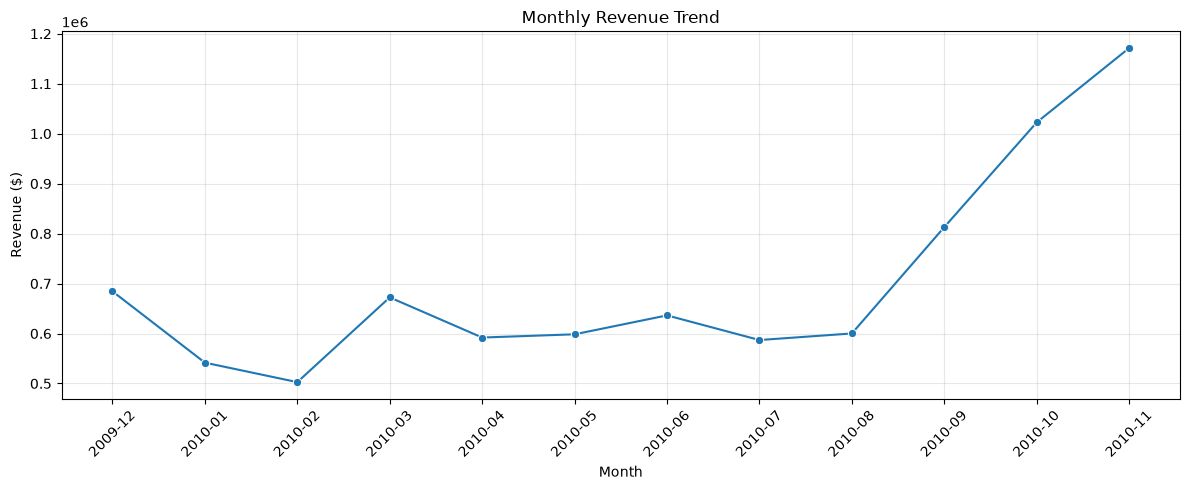

In [71]:
plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_kpi.iloc[:-1], x="Month", y="Revenue", marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('Monthly Revenue Trend.png',dpi=400)
plt.show()

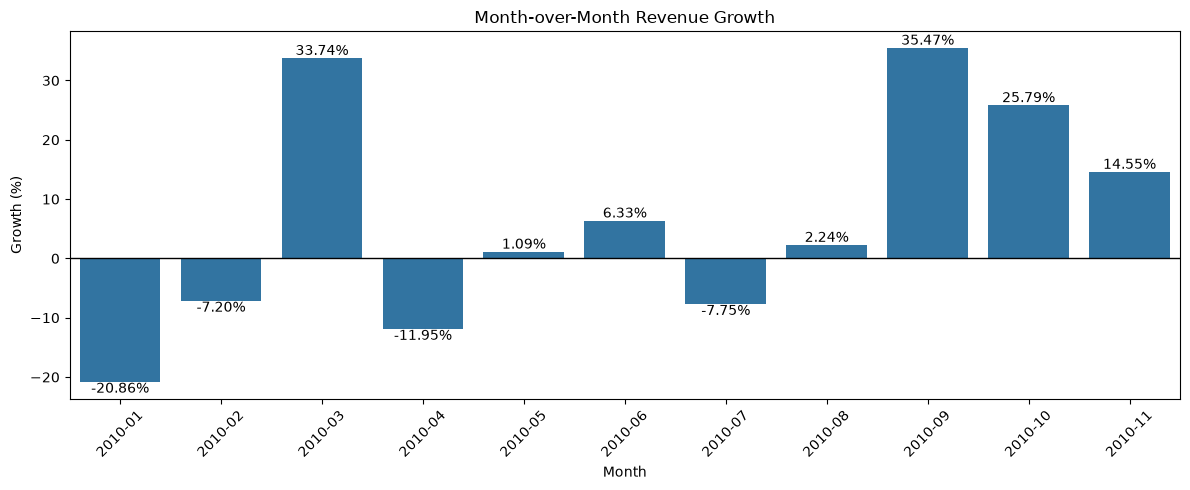

In [72]:
plt.figure(figsize=(12,5))
ax=sns.barplot(
    data=monthly_kpi.iloc[1:-1],
    x="Month",
    y="Revenue Growth %"
)
for container in ax.containers:
    ax.bar_label(container,fmt="%.2f%%")
plt.axhline(0, color="black", linewidth=1)
plt.title("Month-over-Month Revenue Growth")
plt.xlabel("Month")
plt.ylabel("Growth (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Month-over-Month Revenue Growth.png',dpi=400)
plt.show()

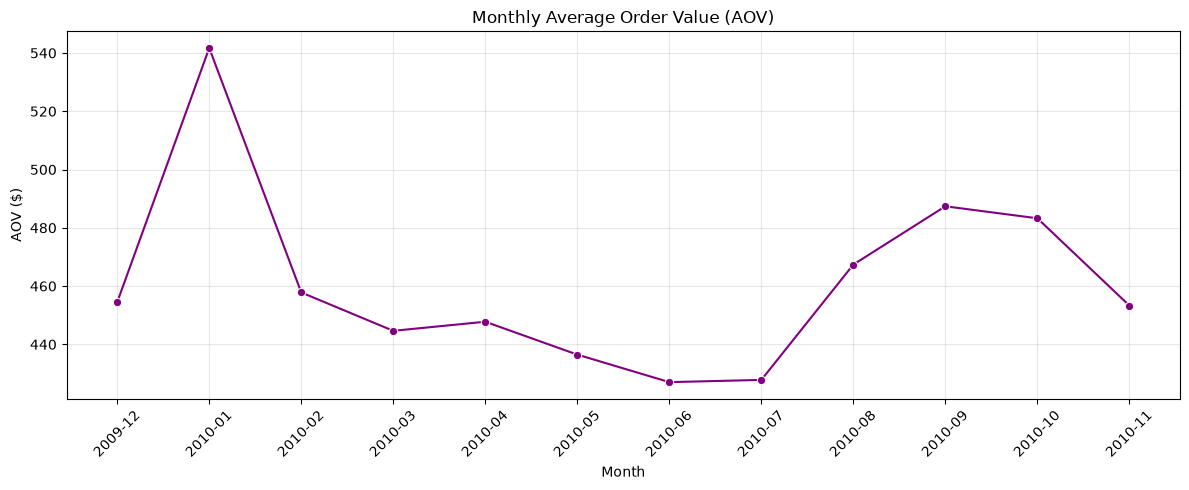

In [73]:
plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_kpi.iloc[:-1], x="Month", y="AOV", marker="o",color='purple')
plt.title("Monthly Average Order Value (AOV)")
plt.xlabel("Month")
plt.ylabel("AOV ($)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('Monthly Average Order Value.png',dpi=400)
plt.show()

### Customer Behavior Analysis

In [74]:
customer_summary=df1.groupby('Customer ID').agg(Orders=('Invoice','nunique'),Revenue=('Revenue','sum')).reset_index()
customer_summary

,Customer ID,Orders,Revenue
0,12346.0,11,372.86
1,12347.0,2,1323.32
2,12348.0,1,222.16
3,12349.0,3,2671.14
4,12351.0,1,300.93
...,...,...,...
4293,18283.0,6,641.77
4294,18284.0,1,461.68
4295,18285.0,1,427.00
4296,18286.0,2,1296.43


In [75]:
customer_summary['AOV']=(customer_summary['Revenue']/customer_summary['Orders'])

In [76]:
customer_summary

,Customer ID,Orders,Revenue,AOV
0,12346.0,11,372.86,33.896364
1,12347.0,2,1323.32,661.660000
2,12348.0,1,222.16,222.160000
3,12349.0,3,2671.14,890.380000
4,12351.0,1,300.93,300.930000
...,...,...,...,...
4293,18283.0,6,641.77,106.961667
4294,18284.0,1,461.68,461.680000
4295,18285.0,1,427.00,427.000000
4296,18286.0,2,1296.43,648.215000


In [77]:
customer_summary.shape

(4298, 4)

In [78]:
#Average revenue per customer
customer_summary["Revenue"].mean()

np.float64(2031.978276872964)

In [79]:
#Median revenue per customer
customer_summary["Revenue"].median()

np.float64(706.02)

In [80]:
#Average orders per customer
customer_summary["Orders"].mean()

np.float64(4.443462075383899)

In [81]:
# Median Orders per customer
customer_summary["Orders"].median()

np.float64(2.0)

In [82]:
#Highest customer revenue
customer_summary["Revenue"].max()

np.float64(349164.35)

In [83]:
customer_summary.loc[customer_summary["Revenue"].idxmax()]

Customer ID     18102.000000
Orders             89.000000
Revenue        349164.350000
AOV              3923.194944
Name: 4169, dtype: float64

In [84]:
customer_summary.loc[customer_summary["Revenue"]==349164.35]

,Customer ID,Orders,Revenue,AOV
4169,18102.0,89,349164.35,3923.194944


In [85]:
customer_summary = customer_summary.sort_values( "Revenue",ascending=False)
top_10_pct = int(len(customer_summary) * 0.10)
top_10_revenue = customer_summary.head(top_10_pct)["Revenue"].sum()
print(top_10_pct,top_10_revenue)

429 5207650.075999999


In [86]:
# top 10 revenue contribution-
top_10_share = top_10_revenue / customer_summary["Revenue"].sum() * 100
top_10_share

np.float64(59.628834747550705)

## Customer Analysis

### Customer Overview

- The cleaned dataset contains **4,298 unique customers**.
- On average, each customer generated **USD 2,031.98** in revenue and placed **4.44 orders** during the analysis period.
- The **median customer** generated only **USD 706.02** from **2 orders**, which is substantially lower than the average.
- This large gap between the **mean and median** indicates a **right-skewed customer revenue distribution**, where a relatively small number of customers contribute disproportionately high revenue.
- The highest-value customer (**Customer ID: 18102**) generated **USD 349,164.35** from **89 orders**, with an average order value of **USD 3,923.19**.
- The **top 10% of customers (429 customers)** contributed **59.63% of total revenue**, highlighting a strong concentration of revenue among high-value customers.

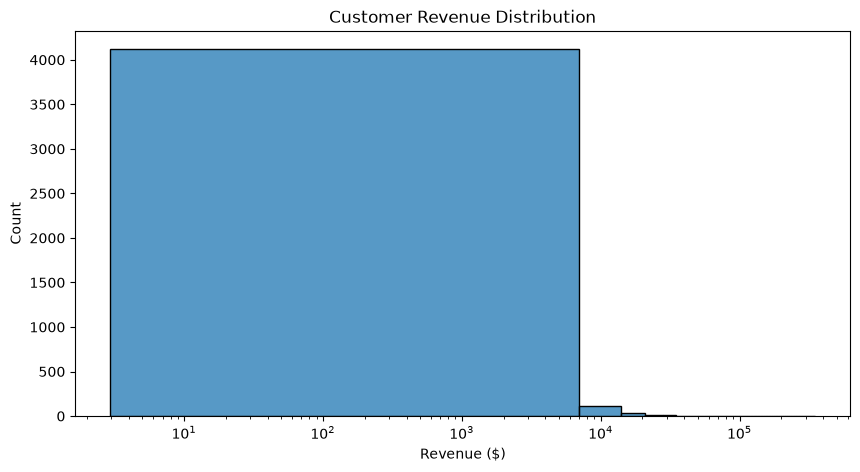

In [87]:
plt.figure(figsize=(10,5))
sns.histplot(customer_summary["Revenue"], bins=50)
plt.xscale("log")
plt.title("Customer Revenue Distribution")
plt.xlabel("Revenue ($)")
plt.show()

In [88]:
customer_summary.head(10)

,Customer ID,Orders,Revenue,AOV
4169,18102.0,89,349164.35,3923.194944
1631,14646.0,78,248396.50,3184.570513
1266,14156.0,97,188388.29,1942.147320
1831,14911.0,188,144142.25,766.714096
937,13694.0,94,131443.19,1398.331809
3731,17511.0,31,84541.17,2727.134516
1942,15061.0,86,83282.93,968.406163
3116,16684.0,27,80489.21,2981.081852
3165,16754.0,29,65500.07,2258.623103
505,13089.0,109,57912.03,531.303028


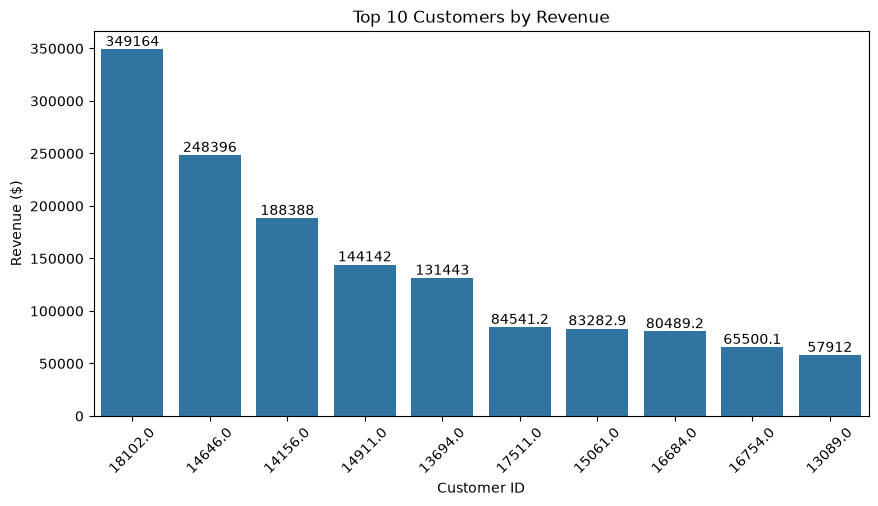

In [127]:
plt.figure(figsize=(10,5))
top10 = customer_summary.sort_values("Revenue", ascending=False).head(10)
ax = sns.barplot(data=top10.head(10), x='Customer ID',y="Revenue", order=top10['Customer ID'])

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container)
plt.savefig('Top 10 Customers by Revenue.png',dpi=400)
plt.show()

In [91]:
country_summary = (df1.groupby("Country").agg(Revenue=("Revenue", "sum"),Orders=("Invoice", "nunique"),
        Customers=("Customer ID", "nunique"),
        Quantity=("Quantity", "sum")).sort_values("Revenue", ascending=False)).reset_index()
country_summary

,Country,Revenue,Orders,Customers,Quantity
0,United Kingdom,7361291.203,17546,3956,4445994
1,EIRE,339901.440,294,5,181406
2,Netherlands,268589.320,130,22,183611
3,Germany,201620.301,344,67,108719
4,France,141194.720,233,47,162199
5,Sweden,51421.710,66,16,52427
6,Denmark,50906.850,26,9,229690
7,Spain,46190.430,64,25,22854
8,Switzerland,43921.390,40,14,22255
9,Australia,30313.350,35,15,20184


In [92]:
country_summary["AOV"] = (country_summary["Revenue"] / country_summary["Orders"]).round(2)
country_summary

,Country,Revenue,Orders,Customers,Quantity,AOV
0,United Kingdom,7361291.203,17546,3956,4445994,419.54
1,EIRE,339901.440,294,5,181406,1156.13
2,Netherlands,268589.320,130,22,183611,2066.07
3,Germany,201620.301,344,67,108719,586.11
4,France,141194.720,233,47,162199,605.99
5,Sweden,51421.710,66,16,52427,779.12
6,Denmark,50906.850,26,9,229690,1957.96
7,Spain,46190.430,64,25,22854,721.73
8,Switzerland,43921.390,40,14,22255,1098.03
9,Australia,30313.350,35,15,20184,866.10


In [93]:
# revenue contribution 
country_summary["Revenue %"] = (country_summary["Revenue"]/ country_summary["Revenue"].sum() * 100).round(2)

In [94]:
country_summary

,Country,Revenue,Orders,Customers,Quantity,AOV,Revenue %
0,United Kingdom,7361291.203,17546,3956,4445994,419.54,84.29
1,EIRE,339901.440,294,5,181406,1156.13,3.89
2,Netherlands,268589.320,130,22,183611,2066.07,3.08
3,Germany,201620.301,344,67,108719,586.11,2.31
4,France,141194.720,233,47,162199,605.99,1.62
5,Sweden,51421.710,66,16,52427,779.12,0.59
6,Denmark,50906.850,26,9,229690,1957.96,0.58
7,Spain,46190.430,64,25,22854,721.73,0.53
8,Switzerland,43921.390,40,14,22255,1098.03,0.50
9,Australia,30313.350,35,15,20184,866.10,0.35


In [95]:
# Number of countries
country_summary["Country"].nunique()

37

In [96]:
# Highest revenue country
country_summary.iloc[0]

Country      United Kingdom
Revenue         7361291.203
Orders                17546
Customers              3956
Quantity            4445994
AOV                  419.54
Revenue %             84.29
Name: 0, dtype: object

In [97]:
# Average revenue per country
country_summary["Revenue"].mean()

np.float64(236038.9901081081)

In [98]:
# Median revenue
country_summary["Revenue"].median()

np.float64(9722.02)

In [99]:
top5_share = country_summary.head(5)["Revenue %"].sum()
print(round(top5_share, 2))

95.19


/var/folders/3x/47d_c4j12256z97nv919ddch0000gn/T/ipykernel_1484/3231008328.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top10,x="Revenue", y="Country", palette='Reds_r')


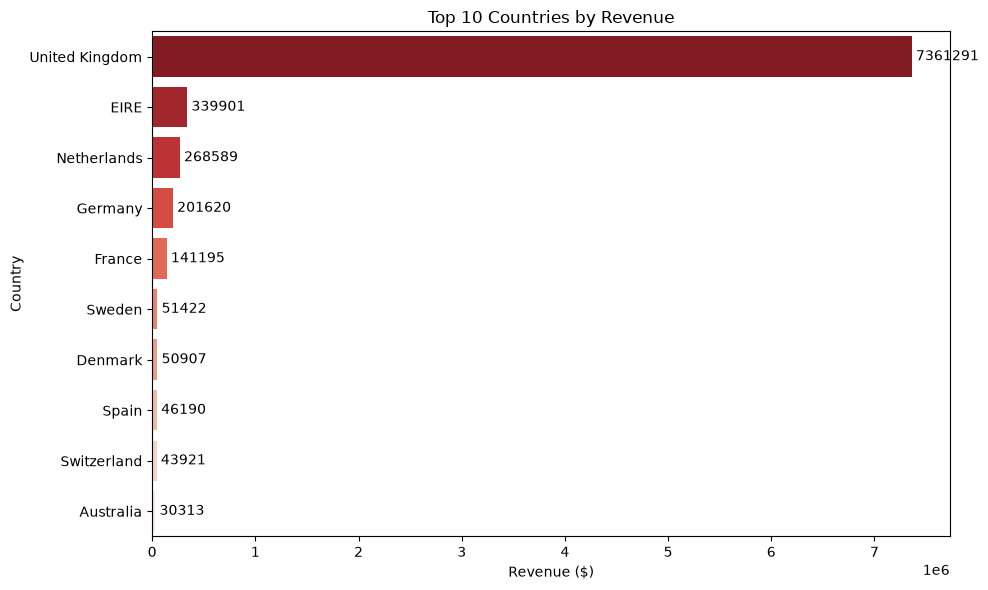

In [100]:
top10 = country_summary.head(10)

plt.figure(figsize=(10,6))

ax = sns.barplot(data=top10,x="Revenue", y="Country", palette='Reds_r')

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Country")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

/var/folders/3x/47d_c4j12256z97nv919ddch0000gn/T/ipykernel_1484/1313582394.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top10,x="Revenue %",y="Country", palette="Blues_r")


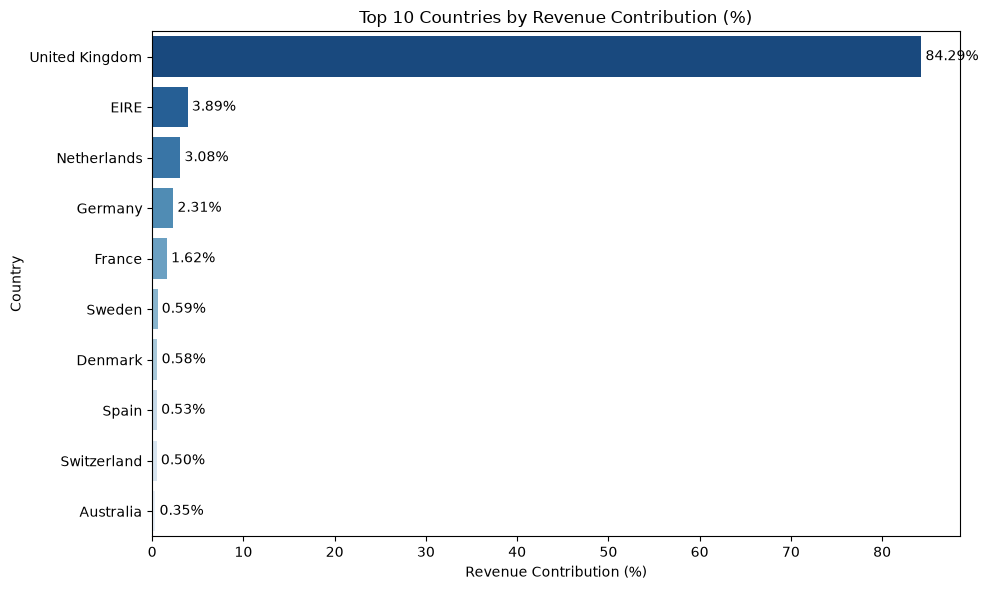

In [101]:
top10 = country_summary.head(10)

plt.figure(figsize=(10,6))

ax = sns.barplot(data=top10,x="Revenue %",y="Country", palette="Blues_r")

plt.title("Top 10 Countries by Revenue Contribution (%)")
plt.xlabel("Revenue Contribution (%)")
plt.ylabel("Country")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.tight_layout()
plt.savefig('Top 10 Countries by Revenue Contribution (%).png',dpi=400)
plt.show()

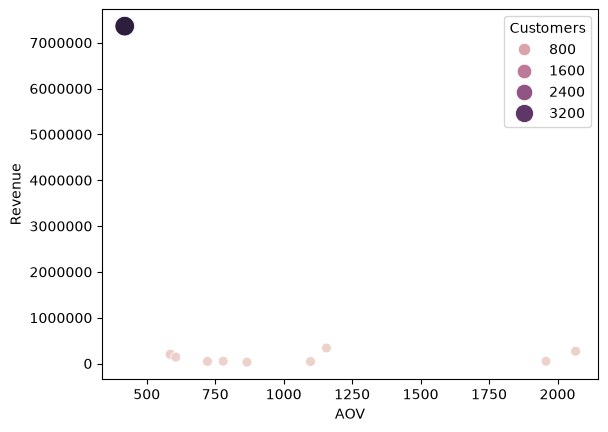

In [102]:
sns.scatterplot(data=top10,x="AOV",y="Revenue",size="Customers",hue="Customers",sizes=(50, 200))
plt.ticklabel_format(style='plain', axis='y')

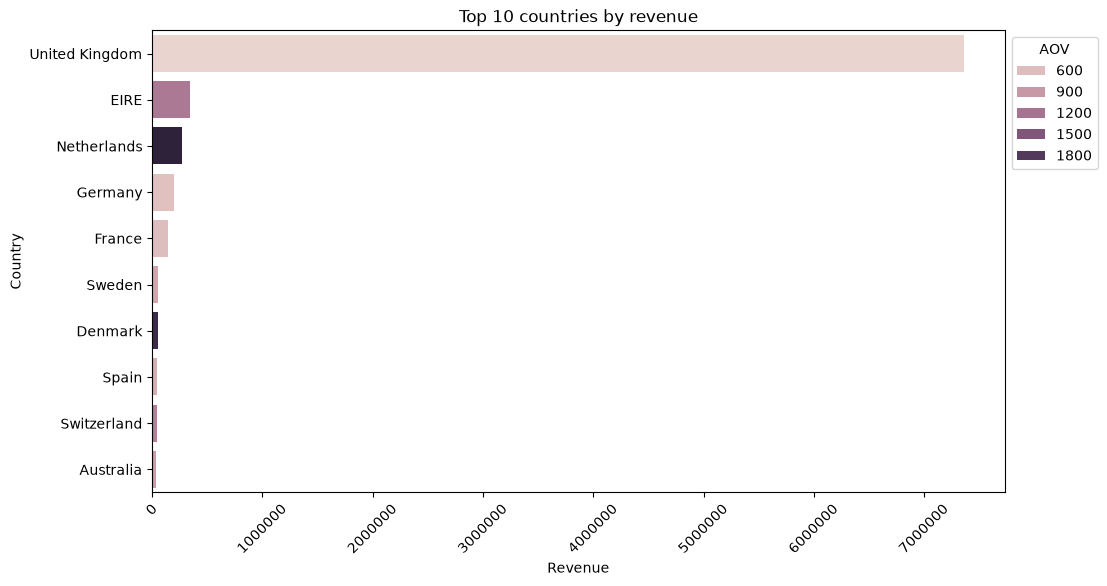

In [103]:
plt.figure(figsize=(11,6))
sns.barplot(top10, y='Country', x='Revenue', hue='AOV')
plt.xticks(rotation=45)
plt.legend( bbox_to_anchor=(1,1),loc="upper left", title='AOV')
plt.ticklabel_format(style='Plain', axis='x')

plt.title('Top 10 countries by revenue')
plt.savefig('Top 10 Countries by Revenue.png',dpi=400)
plt.show()

/var/folders/3x/47d_c4j12256z97nv919ddch0000gn/T/ipykernel_1484/2914733884.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=country_summary.sort_values("AOV", ascending=False).head(20),x="AOV",y="Country", palette='Blues_r')


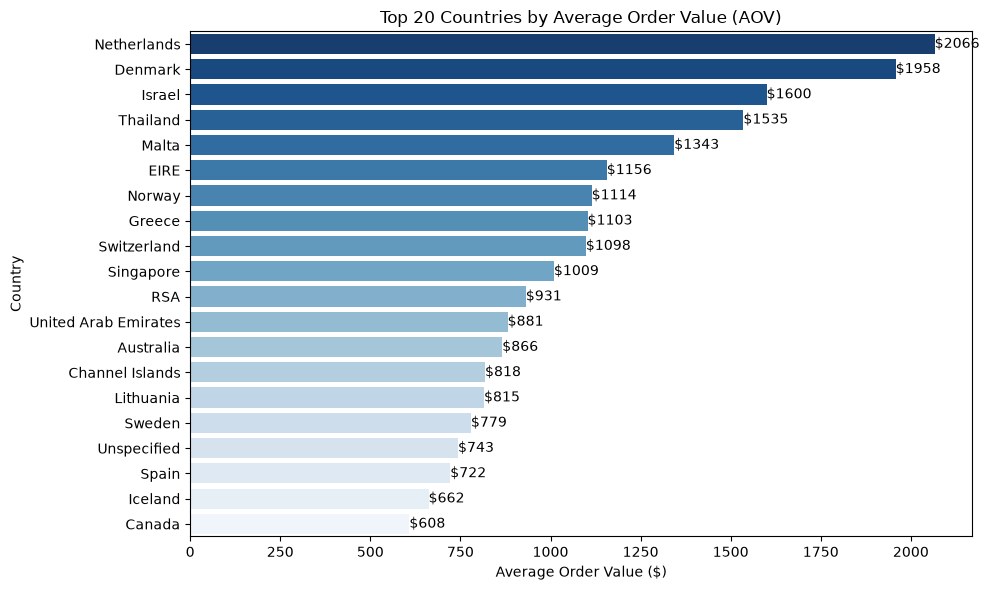

In [104]:
plt.figure(figsize=(10,6))
ax = sns.barplot(data=country_summary.sort_values("AOV", ascending=False).head(20),x="AOV",y="Country", palette='Blues_r')

plt.title("Top 20 Countries by Average Order Value (AOV)")
plt.xlabel("Average Order Value ($)")
plt.ylabel("Country")

for container in ax.containers:
    ax.bar_label(container, fmt="$%.0f")

plt.tight_layout()
plt.savefig('Top 20 Countries by Average Order Value (AOV).png',dpi=400)
plt.show()

## Country Analysis - Key Insights

- The business operates across **37 countries**, indicating a broad international presence.
- The **United Kingdom** is the primary market, generating **84.29% of total revenue** (USD 7.36M), with **17,546 orders** from **3,956 customers**.
- Revenue is **highly concentrated**, with the **top 5 countries contributing 95.19% of total revenue**. This suggests the business relies heavily on a small number of key markets.
- **EIRE, Netherlands, Germany, and France** are the largest international markets, but each contributes less than **4%** of total revenue individually.
- The **median revenue per country (USD 9,722)** is significantly lower than the **average revenue per country (USD 236,039)**, indicating a highly skewed revenue distribution.
- Countries such as the **Netherlands, Denmark, and EIRE** have notably **higher Average Order Values (AOV)** than the UK, suggesting fewer but larger wholesale orders.

In [105]:
product_summary = (df1.groupby(["StockCode", "Description"]).agg(
        Revenue=("Revenue", "sum"),
        Quantity=("Quantity", "sum"),
        Orders=("Invoice", "nunique")).sort_values("Revenue", ascending=False).reset_index())

product_summary

,StockCode,Description,Revenue,Quantity,Orders
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,151624.310,56915,3021
1,22423,REGENCY CAKESTAND 3 TIER,143893.350,12497,1687
2,84879,ASSORTED COLOUR BIRD ORNAMENT,70493.830,44551,1333
3,85099B,JUMBO BAG RED RETROSPOT,51759.300,29578,1060
4,POST,POSTAGE,48741.080,2212,738
...,...,...,...,...,...
4466,79151B,"SILICON CUBE 25W, BLUE",0.420,1,1
4467,35930,PINK HEART CHRISTMAS DECORATION,0.380,1,1
4468,84205C,HAPPY BIRTHDAY GINGER CAT CARD,0.380,2,1
4469,84206C,CHAMPAGNE TRAY BLANK CARD,0.380,2,2


In [106]:
product_summary.head(10)

,StockCode,Description,Revenue,Quantity,Orders
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,151624.31,56915,3021
1,22423,REGENCY CAKESTAND 3 TIER,143893.35,12497,1687
2,84879,ASSORTED COLOUR BIRD ORNAMENT,70493.83,44551,1333
3,85099B,JUMBO BAG RED RETROSPOT,51759.30,29578,1060
4,POST,POSTAGE,48741.08,2212,738
5,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,40186.65,21591,244
6,22086,PAPER CHAIN KIT 50'S CHRISTMAS,36933.50,13860,796
7,47566,PARTY BUNTING,35035.90,8316,710
8,15056N,EDWARDIAN PARASOL NATURAL,34044.75,7201,496
9,85099F,JUMBO BAG STRAWBERRY,33957.45,19291,876


In [107]:
product_summary[product_summary["StockCode"].str.fullmatch(r"[A-Za-z ]+", na=False)]

,StockCode,Description,Revenue,Quantity,Orders
4,POST,POSTAGE,48741.080,2212,738
995,ADJUST,Adjustment by john on 26/01/2010 16,2107.410,18,18
1307,ADJUST,Adjustment by john on 26/01/2010 17,1431.110,14,14
2500,D,Discount,397.890,196,5
2842,BANK CHARGES,Bank Charges,270.000,18,18
4016,BANK CHARGES,Bank Charges,30.000,2,2
4470,PADS,PADS TO MATCH ALL CUSHIONS,0.014,14,14


In [108]:
exclude = ["POST", "ADJUST", "D", "BANK CHARGES", "PADS"]
df1=df1[~df1["StockCode"].isin(exclude)]
product_summary = product_summary[~product_summary["StockCode"].isin(exclude)]
product_summary 

,StockCode,Description,Revenue,Quantity,Orders
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,151624.31,56915,3021
1,22423,REGENCY CAKESTAND 3 TIER,143893.35,12497,1687
2,84879,ASSORTED COLOUR BIRD ORNAMENT,70493.83,44551,1333
3,85099B,JUMBO BAG RED RETROSPOT,51759.30,29578,1060
5,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,40186.65,21591,244
...,...,...,...,...,...
4465,84206B,CAT W SUNGLASSES BLANK CARD,0.76,4,1
4466,79151B,"SILICON CUBE 25W, BLUE",0.42,1,1
4467,35930,PINK HEART CHRISTMAS DECORATION,0.38,1,1
4468,84205C,HAPPY BIRTHDAY GINGER CAT CARD,0.38,2,1


### Product Data Cleaning

Before analyzing product performance, operational stock codes were identified and excluded from the analysis. These included postage charges (`POST`), accounting adjustments (`ADJUST`), discounts (`D`), bank charges (`BANK CHARGES`), and placeholder entries (`PADS`). Since these records do not represent physical products, excluding them ensures that the analysis reflects actual merchandise performance.

In [109]:
# Total unique products
product_summary["StockCode"].nunique()

4011

In [110]:
# Average revenue per product
product_summary["Revenue"].mean()

np.float64(1944.5486402329748)

In [111]:
# Median revenue per product
product_summary["Revenue"].median()

np.float64(528.725)

In [112]:
# Highest revenue product
product_summary.iloc[0]

StockCode                                  85123A
Description    WHITE HANGING HEART T-LIGHT HOLDER
Revenue                                 151624.31
Quantity                                    56915
Orders                                       3021
Name: 0, dtype: object

In [113]:
# Highest quantity sold
product_summary.sort_values("Quantity", ascending=False).head(1)

,StockCode,Description,Revenue,Quantity,Orders
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,151624.31,56915,3021


In [114]:
# Most frequently ordered product
product_summary.sort_values("Orders", ascending=False).head(1)

,StockCode,Description,Revenue,Quantity,Orders
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,151624.31,56915,3021


In [115]:
# revenue contribution for top 10 products
top10_share = (product_summary.head(10)["Revenue"].sum()/ product_summary["Revenue"].sum() * 100)

print(round(top10_share, 2),'%')

7.28 %


/var/folders/3x/47d_c4j12256z97nv919ddch0000gn/T/ipykernel_1484/3205574944.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top10,x="Revenue",y="Description", palette='Reds_r')


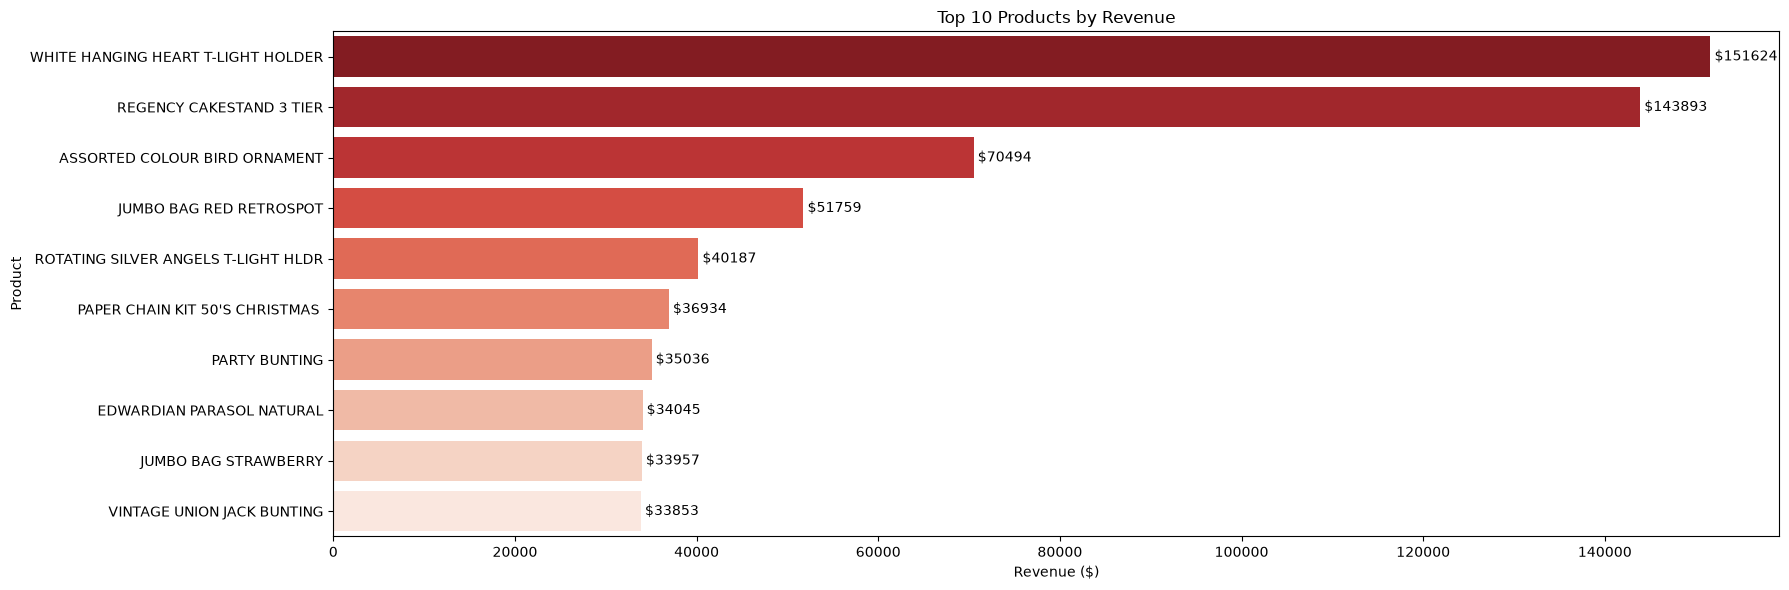

In [116]:
top10 = product_summary.head(10)

plt.figure(figsize=(18,6))

ax = sns.barplot(data=top10,x="Revenue",y="Description", palette='Reds_r')

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Product")

for container in ax.containers:
    ax.bar_label(container, fmt="$%.0f", padding=3)

plt.tight_layout()
plt.savefig('Top 10 Products by Revenue.png',dpi=400)
plt.show()

In [117]:
product_summary = product_summary.sort_values("Revenue", ascending=False)

product_summary["Cumulative Revenue %"] = (product_summary["Revenue"].cumsum()/ product_summary["Revenue"].sum()* 100)

product_summary.head()

,StockCode,Description,Revenue,Quantity,Orders,Cumulative Revenue %
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,151624.31,56915,3021,1.746730
1,22423,REGENCY CAKESTAND 3 TIER,143893.35,12497,1687,3.404399
2,84879,ASSORTED COLOUR BIRD ORNAMENT,70493.83,44551,1333,4.216496
3,85099B,JUMBO BAG RED RETROSPOT,51759.30,29578,1060,4.812770
5,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,40186.65,21591,244,5.275725


In [118]:
products_80 = (product_summary["Cumulative Revenue %"] <= 80).sum()
print(products_80)

1003


In [119]:
#pareto analysis(% of the products generate 80% of total revenue)
products_80/product_summary["StockCode"].nunique()*100

np.float64(25.006232859636)

### Pareto Analysis (80/20 Rule)

- The business offers **4,011 unique products**.
- Approximately **1,003 products (25%) account for 80% of total revenue**.
- This indicates that the business **does not strictly follow the classic Pareto (80/20) principle**, where 20% of products generate 80% of revenue.
- Instead, revenue is distributed across a broader range of products, suggesting a **well-diversified product portfolio** with many products contributing meaningfully to overall sales.

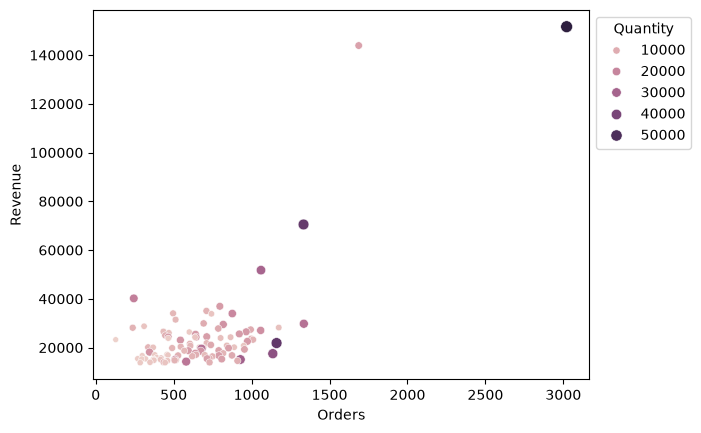

In [120]:
top100 = product_summary.head(100)

sns.scatterplot(data=top100,x="Orders",y="Revenue",size="Quantity",hue="Quantity")
plt.legend(bbox_to_anchor=(1,1), loc='upper left', title='Quantity')

In [121]:
#new notebook for cohort+ rfm analysis
df1.to_excel("clean_data.xlsx", index=False)